# Test: Paso de adsorción PSA — Columna Zeolite 13X / CO₂–CH₄

Adaptación del antiguo `test_steps_psa` (basado en la clase `column.py`) a la
nueva arquitectura modular. Ejecuta un único paso de adsorción de 600 s y
reproduce las visualizaciones equivalentes a los métodos `Graph_*` originales
mediante las funciones de `src.postprocessing.variables_plot`.

| Antiguo (`column.py`)                     | Nuevo (API modular)                               |
|-------------------------------------------|---------------------------------------------------|
| `CR1._gas_prop_info(...)`                 | `build_gas_prop_config(...)`                      |
| `CR1._adsorbent_info(...)`                | `build_adsorbent_config(...)`                     |
| `CR1._transport_info(...)`                | `build_transport_config(...)`                     |
| `CR1._thermal_boundary_info(...)`         | `build_thermal_bc_config(...)`                    |
| `CR1._boundaryC_info(...)`                | `build_boundary_c_config(...)`                    |
| `CR1._initialC_info(...)` + `_initColumn()` | `build_initial_c_config(...)` + `pack_state_vector(...)` |
| `CR1.run_mamoen(mode="ads", ...)`         | `run_step("ads", sv0, t_max, params, ...)`        |
| `CR1._checkBalances()` / `printBalances()` | `balance_report(col, params)`                   |
| `CR1.Graph_P/v/Tg/Ts(every_n_sec=60)`    | `Graph_P/v/Tg/Ts(col, plot_every=[0,60,...,600])`|
| `CR1.Graph_C_species(i, every_n_sec=60)` | `Graph_y(col, plot_every=...)`                    |


## 1. Imports

In [1]:
import os, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.utils.isotherm_fitting import fit_single_T
from src.utils.isotherm_models  import arrh

from src.units.adsorber.config.gas_props  import build_gas_prop_config
from src.units.adsorber.config.adsorbent  import build_adsorbent_config
from src.units.adsorber.config.transport  import build_transport_config
from src.units.adsorber.config.thermal_bc import build_thermal_bc_config
from src.units.adsorber.config.boundary_c import build_boundary_c_config
from src.units.adsorber.config.initial_c  import build_initial_c_config
from src.units.adsorber.state             import pack_state_vector

from src.solvers.runner_adsorption import run_step
from src.postprocessing.adsorber_balances   import balance_report
from src.postprocessing.variables_plot import (
    Graph_P, Graph_Tg, Graph_Ts, Graph_v,
    Graph_y, Graph_y_i, Graph_C, Graph_C_i,
    Graph_q, Graph_q_i,
)

DB_PATH   = os.path.join(ROOT, "materials", "fluids", "gasdb.txt")
DATA_PATH = os.path.join(os.getcwd(), "data", "Zeolite13X.csv")

print("Imports OK")
print("gasdb existe :", os.path.isfile(DB_PATH))
print("datos existen:", os.path.isfile(DATA_PATH))

Imports OK
gasdb existe : True
datos existen: True


## 2. Isotermas

Ajuste DSL a datos experimentales de Zeolite 13X (CO₂/CH₄) con
`fit_single_T` + corrección de Arrhenius para dependencia en temperatura.
Equivalente al antiguo `isofitLibs.best_isomodel + iso2isoArr`.


In [2]:
df_iso = pd.read_csv(DATA_PATH)
P_CO2  = df_iso["Pressure_CO2 (bar)"].dropna().values
q_CO2  = df_iso["Uptake_CO2 (mol/kg)"].dropna().values
P_CH4  = df_iso["Pressure_CH4 (bar)"].dropna().values
q_CH4  = df_iso["Uptake_CH4 (mol/kg)"].dropna().values

T_REF  = 298.15    # K
dH_CO2 = 31.164e3  # J/mol
dH_CH4 =  9.856e3  # J/mol

iso_CO2_P, par_CO2, name_CO2, _ = fit_single_T(P_CO2, q_CO2)
iso_CH4_P, par_CH4, name_CH4, _ = fit_single_T(P_CH4, q_CH4)

def iso_CO2_PT(P_bar, T_K):
    return iso_CO2_P(np.asarray(P_bar) * arrh(float(T_K), dH_CO2, T_REF))

def iso_CH4_PT(P_bar, T_K):
    return iso_CH4_P(np.asarray(P_bar) * arrh(float(T_K), dH_CH4, T_REF))

def iso_fn(P_part_list, Ts):
    """iso_fn(P_part_list, Ts) -> q_eq (nc, N) [mol/kg]"""
    Ts_arr = np.asarray(Ts, dtype=float)
    N_loc  = len(Ts_arr)
    q_eq   = np.zeros((2, N_loc), dtype=float)
    for n in range(N_loc):
        q_eq[0, n] = iso_CO2_PT(float(P_part_list[0][n]), Ts_arr[n])
        q_eq[1, n] = iso_CH4_PT(float(P_part_list[1][n]), Ts_arr[n])
    return q_eq

print(f"Isoterma CO2: {name_CO2}  |  CH4: {name_CH4}")


Isoterma CO2: Dual-site Langmuir  |  CH4: Dual-site Langmuir


## 3. Parámetros del sistema

In [3]:
# ── Geometría ──────────────────────────────────────────────────────────────────
N    = 21
L    = 1.35          # m
Di   = 0.30          # m
Do   = 0.35          # m
dz   = L / N
Ai   = 0.25 * np.pi * Di**2
Pi   = np.pi * Di
Po   = np.pi * Do
e_wall = (Do - Di) / 2.0

# ── Adsorbente ────────────────────────────────────────────────────────────────
nc         = 2
SPECIES    = ["CO2", "CH4"]
epsi       = 0.37
D_particle = 12.0e-4    # m
rho_s      = 3200.0     # kg/m3
Cp_s       = 1200.0     # J/kg/K
k_s        = 10.0       # W/m/K
tau_pore   = 3.0
r_pore     = 1.0e-9     # m
dH_ads     = np.array([dH_CO2, dH_CH4])

# ── Condiciones de operación ──────────────────────────────────────────────────
P_inlet  = 9.5          # bar
P_outlet = 9.0          # bar
T_feed   = 323.0        # K
y_feed   = np.array([0.33, 0.67])
Q_feed   = 0.05 * Ai    # m3/s
Cv_in    = 2.5e-1
Cv_out   = 1.5

print(f"Geometria  : L={L} m  Di={Di} m  Do={Do} m  N={N}  dz={dz:.4f} m")
print(f"Adsorbente : epsi={epsi}  rho_s={rho_s} kg/m3  Dp={D_particle*1e3:.1f} mm")
print(f"Operacion  : P={P_inlet}/{P_outlet} bar  T={T_feed} K  y={y_feed}")


Geometria  : L=1.35 m  Di=0.3 m  Do=0.35 m  N=21  dz=0.0643 m
Adsorbente : epsi=0.37  rho_s=3200.0 kg/m3  Dp=1.2 mm
Operacion  : P=9.5/9.0 bar  T=323.0 K  y=[0.33 0.67]


## 4. Construcción del modelo

Los seis bloques `_*_info()` + `_initColumn()` del `column.py` antiguo
expresados como llamadas independientes a funciones `build_*`.


In [4]:
# 1. Propiedades del gas ← CR1._gas_prop_info(mode="constant", ...)
prop_gas = build_gas_prop_config(
    species=SPECIES, mode="constant", n_comp=nc, N=N,
    T_ref=T_feed, db_path=DB_PATH,
)
gas_T_ref = float(np.min(np.asarray(prop_gas["Tref"])))

# 2. Adsorbente + isoterma ← CR1._adsorbent_info(...)
ads_config = build_adsorbent_config(
    iso_fn=iso_fn, n_comp=nc, N=N,
    epsi=epsi, D_particle=D_particle,
    rho_s=rho_s, Cp_solid=Cp_s, k_solid=k_s,
    dH_adsorption=dH_ads, tau=tau_pore, r_pore=r_pore,
)

# 3. Transporte ← CR1._transport_info(mode="correlation")
trans_config = build_transport_config(mode="correlation", n_comp=nc, N=N)

# 4. Condicion termica de pared ← CR1._thermal_boundary_info(mode="ambient_htc", h_ambi=250)
thermal_bc = build_thermal_bc_config(
    mode="ambient_htc", Di=Di, Do=Do, e_wall=e_wall,
    h_ambi=250.0, T_ambi=298.0, k_wall=2.0,
)

# 5. Condiciones de contorno ← CR1._boundaryC_info(...)
bc_config = build_boundary_c_config(
    n_comp=nc, N=N, forward_flow_direction=True,
    Q_in_feed=Q_feed,  P_in_feed=P_inlet,  T_in_feed=T_feed,  y_in_feed=y_feed,
    P_out_ads=P_outlet, Cv_out_ads=Cv_out,
    Q_in_purge=Q_feed, P_in_purge=P_inlet, T_in_purge=T_feed, y_in_purge=y_feed,
    P_out_purge=P_outlet, Cv_out_purge=Cv_out,
    P_high=P_inlet, Cv_in_prfeed=Cv_in,
    P_low=1.0, Cv_out_blowdown=Cv_out, Cv_eq_lm=Cv_out, Cv_eq_mh=Cv_out,
)

# 6. Condiciones iniciales ← CR1._initialC_info(...) + CR1._initColumn()
y_init = np.array([0.01 * np.ones(N), 0.99 * np.ones(N)])
P_init = P_inlet * np.ones(N)
T_init = T_feed  * np.ones(N)

init_config = build_initial_c_config(
    P_init=P_init, Tg_init=T_init, Ts_init=T_init, y_init=y_init,
    n_comp=nc, N=N, iso_fn=ads_config["iso"],
    prop_gas=prop_gas, epsi=epsi, gas_T_ref=gas_T_ref, q_init=None,
)

sv0 = pack_state_vector(
    C=init_config["C_init"], q=init_config["q_init"],
    Hg=init_config["Hg_init"], Ts=init_config["Ts_init"],
)

params = {
    "n_comp": nc,  "N": N,   "dz": dz,
    "Ai": Ai,      "Di": Di, "Pi": Pi, "Po": Po,
    "prop_gas":          prop_gas,
    "MW":                np.asarray(prop_gas["MW"]),
    "gas_T_ref":         gas_T_ref,
    "iso_fn":            ads_config["iso"],
    "epsi":              ads_config["epsi"],
    "rho_s":             ads_config["rho_s"],
    "Cp_s":              ads_config["Cp_s"],
    "k_s":               ads_config["k_s"],
    "dH":                ads_config["dH_comp"],
    "prop_lecho":        ads_config["prop_lecho"],
    "bc_config":         bc_config,
    "trans_config":      trans_config,
    "thermal_bc_config": thermal_bc,
    "prop_update_mode":  "frozen",
    "trans_update_mode": "frozen",
    "energy":            True,
    "Tg_init":           T_init.copy(),
    "species":           SPECIES,
    "_cache":            {},
}

print(f"sv0.shape = {sv0.shape}")
print(f"q_init CO2 media: {init_config['q_init'][0].mean():.4f} mol/kg")
print(f"q_init CH4 media: {init_config['q_init'][1].mean():.4f} mol/kg")
print("Modelo construido OK")


sv0.shape = (126,)
q_init CO2 media: 2.1514 mol/kg
q_init CH4 media: 2.2758 mol/kg
Modelo construido OK


## 5. Simulación — paso de adsorción (600 s)

Equivalente a `CR1.run_mamoen(mode="ads", t_max=600.0, ...)`.

In [5]:
T_MAX  = 600.0
N_SEC  = 20
RTOL   = 1.0e-8
ATOL   = 1.0e-10

t0 = time.perf_counter()
t_arr, y_hist, col = run_step(
    step="ads", sv0=sv0, t_max=T_MAX, params=params,
    solver="solve_ivp", rtol=RTOL, atol=ATOL,
    n_sec=N_SEC, show_progress=True,
)
wall_time = time.perf_counter() - t0

print(f"\nIntegracion completada en {wall_time:.2f} s de CPU")
print(f"Puntos temporales      : {len(t_arr)}")
print(f"col._y_results.shape   : {col._y_results.shape}   (n_t, nc, N)")
print(f"P media final [bar]    : {col._P_results[-1,:].mean():.4f}")
print(f"Tg media final [K]     : {col._Tg_results[-1,:].mean():.4f}")
print(f"Ts media final [K]     : {col._Ts_results[-1,:].mean():.4f}")


step=ads:   0%|          | 0.0/600 s [00:00<?, ?s/s]


Integracion completada en 129.91 s de CPU
Puntos temporales      : 12001
col._y_results.shape   : (12001, 2, 21)   (n_t, nc, N)
P media final [bar]    : 9.3497
Tg media final [K]     : 348.5687
Ts media final [K]     : 348.6031


## 6. Balance de conservación

Equivalente a `CR1._checkBalances()` + `CR1.printBalances()`.

In [6]:
df_bal = balance_report(col, params, include_energy=True, print_report=True)
df_bal


──────────────────────────────────────────────────────────────────────────────────
  INFORME DE BALANCE DE CONSERVACIÓN
──────────────────────────────────────────────────────────────────────────────────
               Acumulación  Flujo neto BC  Error abs  Error rel [%]
Variable                                                           
N_CO2 [mol]        +241.43        +241.76   -0.33154      -0.080081
N_CH4 [mol]        -110.08        -109.91   -0.17134       -0.03408
N_total [mol]      +131.35        +131.85   -0.50288      -0.066994
E_gas [kJ]         +10.322        +4044.8    +476.25        +3.3457
E_solid [kJ]       +5910.6        +5910.4   -0.20648     -0.0034933
E_total [kJ]       +5920.9        +6396.9    +476.04        +7.4417
──────────────────────────────────────────────────────────────────────────────────
  Error máximo: 7.442 %  →  REVISAR    (>5 %)

  Desglose de términos energéticos [kJ]:
    Ein               = +1.423e+04
    Eout              = +1.019e+04
    Qcond_g_

,Acumulación,Flujo neto BC,Error abs,Error rel [%]
Variable,,,,
N_CO2 [mol],+241.43,+241.76,-0.33154,-0.080081
N_CH4 [mol],-110.08,-109.91,-0.17134,-0.03408
N_total [mol],+131.35,+131.85,-0.50288,-0.066994
E_gas [kJ],+10.322,+4044.8,+476.25,+3.3457
E_solid [kJ],+5910.6,+5910.4,-0.20648,-0.0034933
E_total [kJ],+5920.9,+6396.9,+476.04,+7.4417


## 7. Visualización — Perfiles escalares

`variables_plot` genera automáticamente un layout de tres paneles:
**Entrada** (serie temporal en z = 0) | **Perfil axial** (multi-tiempo, jet) | **Salida** (z = L).

`plot_every` como lista de floats selecciona los snapshots más cercanos a esos instantes.
Equivalente a `CR1.Graph_P(every_n_sec=60)`, `CR1.Graph_v(...)`, etc.


C:\Users\MiguelCamaraSanz\OneDrive - Fundacion CIRCE\GITHUB\GasifierSimNet\src\postprocessing\variables_plot.py:226: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


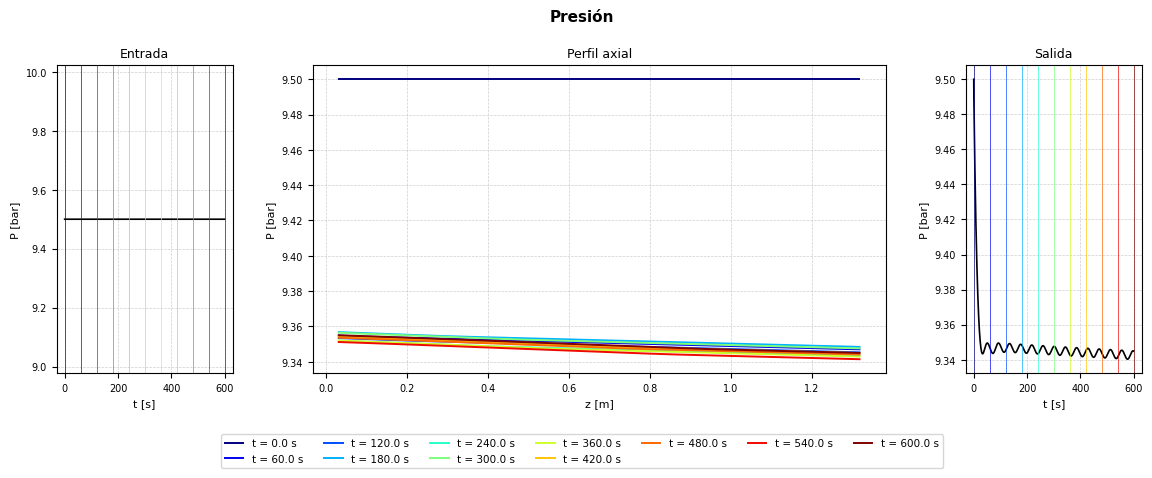

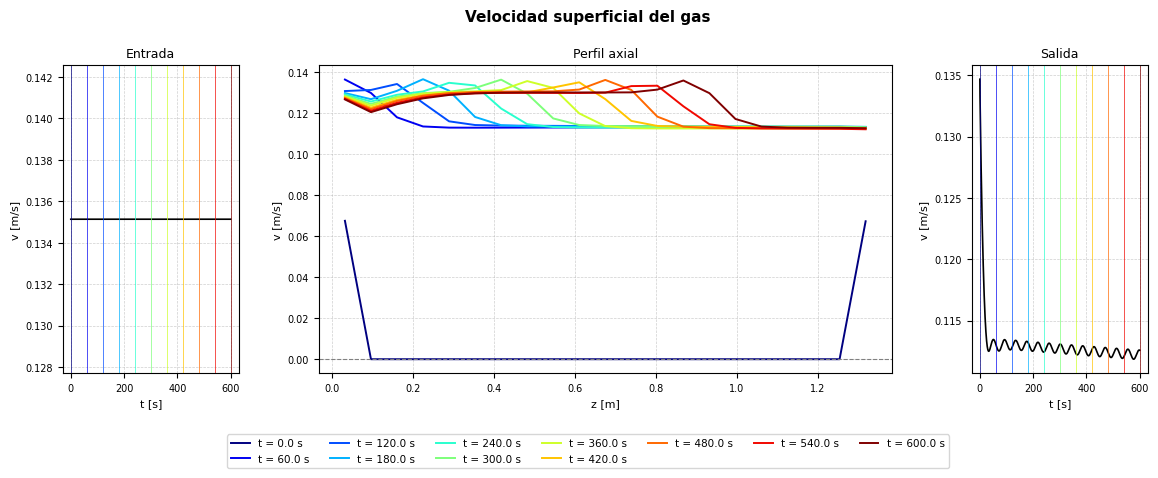

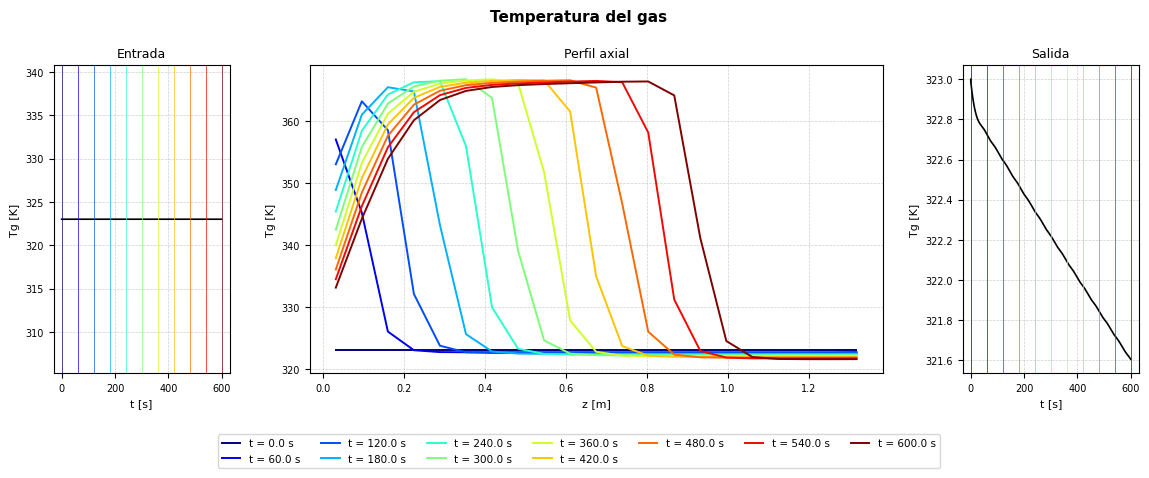

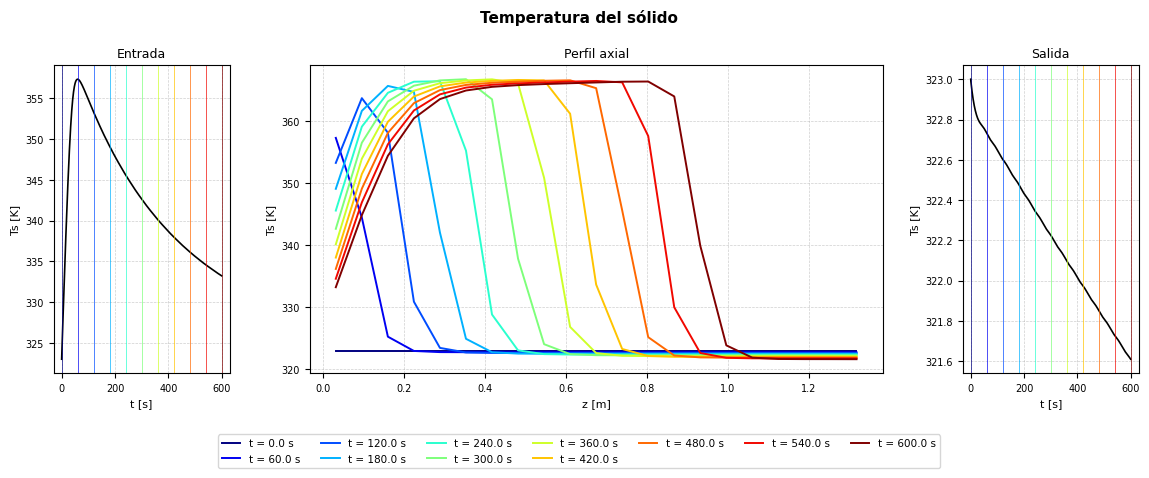

(<Figure size 1400x400 with 3 Axes>,
 (<Axes: title={'center': 'Entrada'}, xlabel='t [s]', ylabel='Ts [K]'>,
  <Axes: title={'center': 'Perfil axial'}, xlabel='z [m]', ylabel='Ts [K]'>,
  <Axes: title={'center': 'Salida'}, xlabel='t [s]', ylabel='Ts [K]'>))

In [7]:
# Tiempos de snapshot [s]: de 0 a T_MAX cada 60 s
PLOT_TIMES = [float(t) for t in range(0, int(T_MAX) + 1, 60)]

Graph_P(col,  plot_every=PLOT_TIMES)
Graph_v(col,  plot_every=PLOT_TIMES)
Graph_Tg(col, plot_every=PLOT_TIMES)
Graph_Ts(col, plot_every=PLOT_TIMES)


## 8. Visualización — Composición y carga adsorbida

`Graph_y` muestra todas las especies en un único gráfico (color = tiempo, linestyle = especie).
`Graph_q` idem para la carga adsorbida.
Equivalente a `CR1.Graph_C_species(0, ...)` + `CR1.Graph_C_species(1, ...)`.


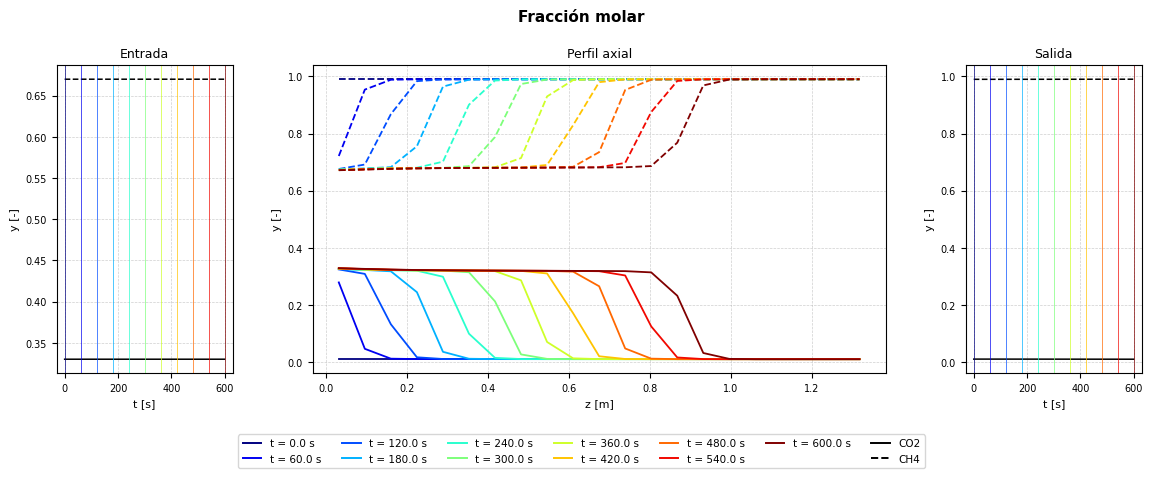

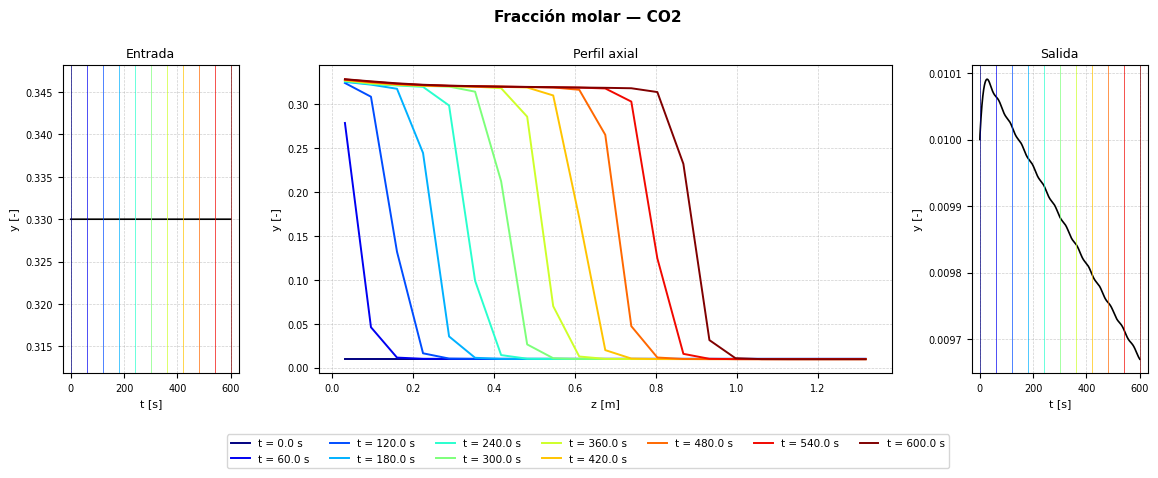

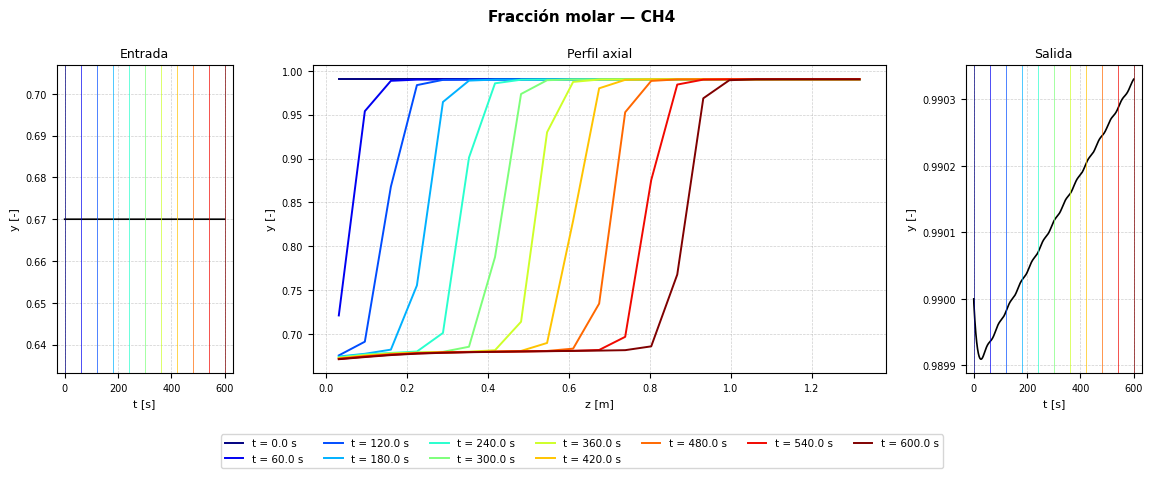

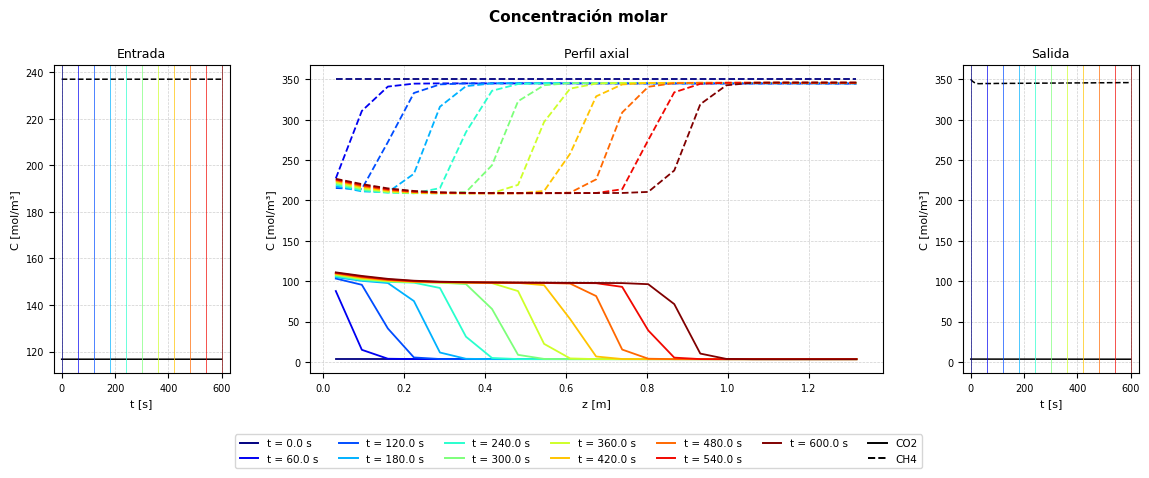

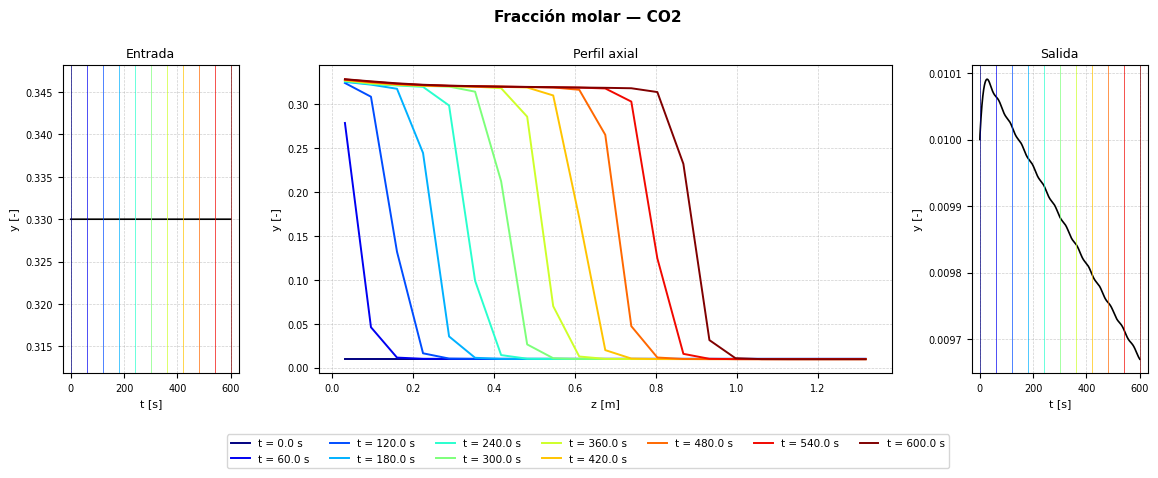

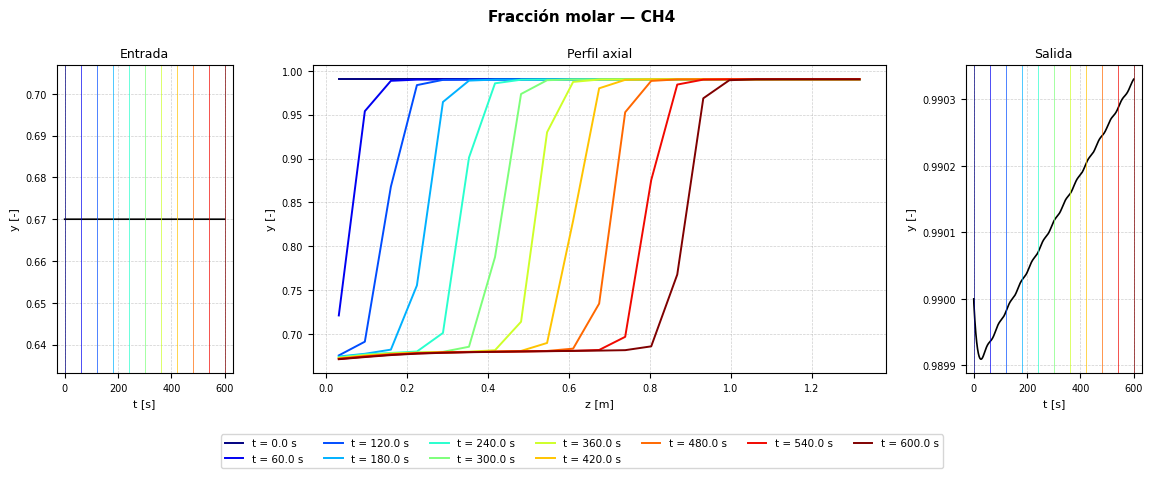

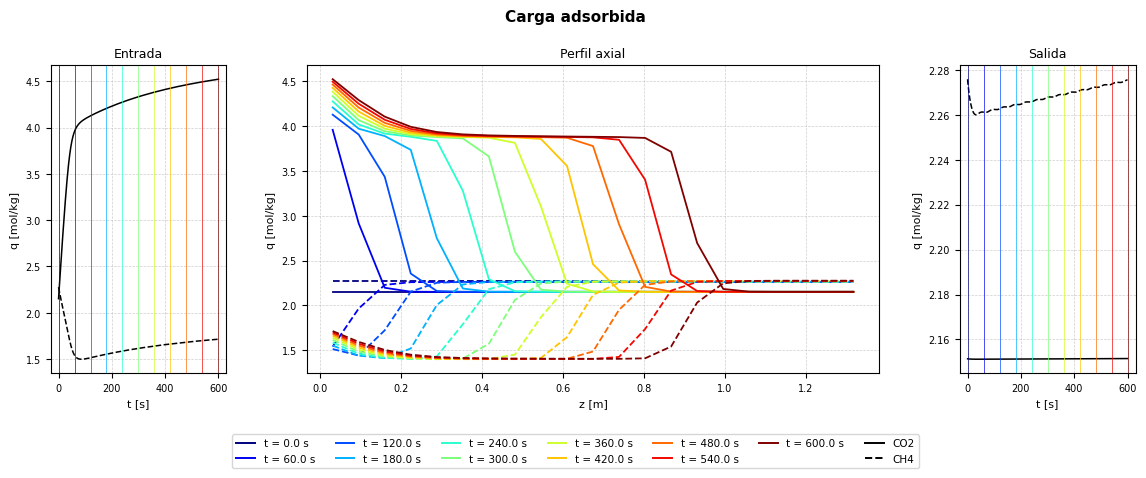

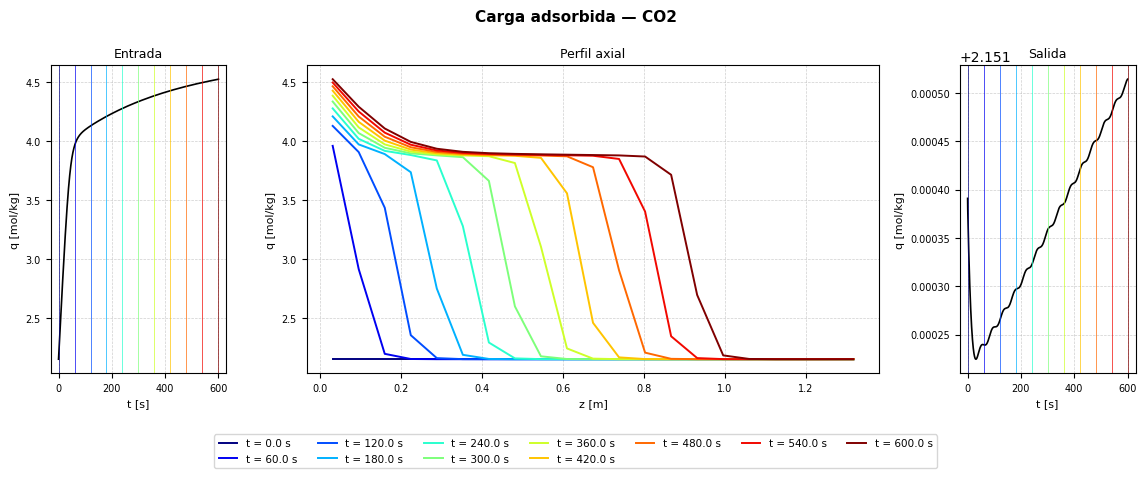

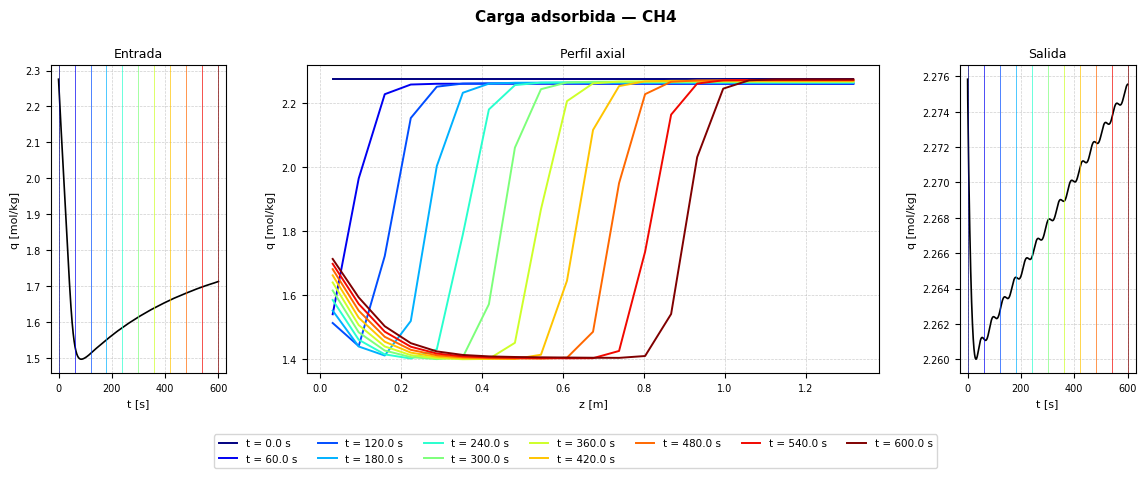

(<Figure size 1400x400 with 3 Axes>,
 (<Axes: title={'center': 'Entrada'}, xlabel='t [s]', ylabel='q [mol/kg]'>,
  <Axes: title={'center': 'Perfil axial'}, xlabel='z [m]', ylabel='q [mol/kg]'>,
  <Axes: title={'center': 'Salida'}, xlabel='t [s]', ylabel='q [mol/kg]'>))

In [8]:
Graph_y(col, plot_every=PLOT_TIMES)   # fracciones molares CO2, CH4
Graph_y_i(col, species_idx=0, plot_every=PLOT_TIMES)   # fracciones molares CO2
Graph_y_i(col, species_idx=1, plot_every=PLOT_TIMES)   # fracciones molares CH4
Graph_C(col, plot_every=PLOT_TIMES)   # concentracione molares CO2, CH4
Graph_y_i(col, species_idx=0, plot_every=PLOT_TIMES)   # concentracion molares CO2
Graph_y_i(col, species_idx=1, plot_every=PLOT_TIMES)   # concentraciones molares CH4
Graph_q(col, plot_every=PLOT_TIMES)   # cargas adsorbidas CO2, CH4
Graph_q_i(col, species_idx=0, plot_every=PLOT_TIMES)   # cargas adsorbidas CO2, CH4
Graph_q_i(col, species_idx=1, plot_every=PLOT_TIMES)   # cargas adsorbidas CO2, CH4


## 9. Resumen final

In [9]:
print("=" * 65)
print("  RESUMEN -- PASO DE ADSORCION  (600 s)")
print("=" * 65)
print(f"  Tiempo de computo          : {wall_time:.2f} s")
print(f"  Puntos temporales          : {len(t_arr)}")
print(f"  Celdas espaciales          : {N}")
print()
print(f"  Estado final (media axial):")
print(f"    P  [bar]  : {col._P_results[-1,:].mean():.4f}")
print(f"    Tg [K]    : {col._Tg_results[-1,:].mean():.4f}")
print(f"    Ts [K]    : {col._Ts_results[-1,:].mean():.4f}")
print(f"    y_CO2 [-] : {col._y_results[-1, 0, :].mean():.4f}")
print(f"    y_CH4 [-] : {col._y_results[-1, 1, :].mean():.4f}")
print()
print(f"  Balances de conservacion:")
for row_key, label in [
    ("N_total [mol]", "Error molar total  "),
    ("E_gas [kJ]",    "Error energia gas  "),
    ("E_total [kJ]",  "Error energia total"),
]:
    try:
        val = df_bal.loc[row_key, "Error rel [%]"]
        print(f"    {label}: {val:+.4f} %")
    except Exception:
        pass
print("=" * 65)


  RESUMEN -- PASO DE ADSORCION  (600 s)
  Tiempo de computo          : 129.91 s
  Puntos temporales          : 12001
  Celdas espaciales          : 21

  Estado final (media axial):
    P  [bar]  : 9.3497
    Tg [K]    : 348.5687
    Ts [K]    : 348.6031
    y_CO2 [-] : 0.2140
    y_CH4 [-] : 0.7860

  Balances de conservacion:
    Error molar total  : -0.0670 %
    Error energia gas  : +3.3457 %
    Error energia total: +7.4417 %
